# Conversion rate challenge

In [157]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "notebook" # to be replaced by "iframe" if working on JULIE
from IPython.display import display


## Exploration des données

In [107]:
# Lecture des fichiers
print("Loading dataset...")
dataset = pd.read_csv("D:/Profils/NLefort/Desktop/JEDHA/PROJETS/05.ML_supervise/Rate_challenge/conversion_data_train.csv")
print("...Done.")

Loading dataset...
...Done.


In [179]:
## Analyse descriptive
# INFORMATIONS GENERALES
print("\n INFORMATIONS GENERALES")
print("-"*40)

print("Nombre de lignes : {}".format(dataset.shape[0]))
print("Nombre de colonnes : {}".format(dataset.shape[1]))

print("Aperçu du dataset : ")
display(dataset.head())

print("Types de données/colonnes : ")
display(dataset.dtypes)



 INFORMATIONS GENERALES
----------------------------------------
Nombre de lignes : 284580
Nombre de colonnes : 7
Aperçu du dataset : 


,country,age,new_user,source,total_pages_visited,converted,age_group
0,China,22,1,Direct,2,0,18-24
1,UK,21,1,Ads,3,0,18-24
2,Germany,20,0,Seo,14,1,18-24
3,US,23,1,Seo,3,0,18-24
4,US,28,1,Direct,3,0,25-34


Types de données/colonnes : 


country                  object
age                       int64
new_user                  int64
source                   object
total_pages_visited       int64
converted                 int64
age_group              category
dtype: object

In [109]:
# VALEURS MANQUANTES
print(f"Nombre de valeurs manquantes par colonne : \n{dataset.isnull().sum()}")


Nombre de valeurs manquantes par colonne : 
country                0
age                    0
new_user               0
source                 0
total_pages_visited    0
converted              0
dtype: int64


In [96]:
# STATISTIQUES DESCRIPTIVES
# Statistiques descriptives globales
print("Statistiques descriptives globales :")
display(dataset.describe(include="all").round(2))

Statistiques descriptives globales :


,country,age,new_user,source,total_pages_visited,converted
count,284580,284580.00,284580.00,284580,284580.00,284580.00
unique,4,NaN,NaN,3,NaN,NaN
top,US,NaN,NaN,Seo,NaN,NaN
freq,160124,NaN,NaN,139477,NaN,NaN
mean,NaN,30.56,0.69,NaN,4.87,0.03
std,NaN,8.27,0.46,NaN,3.34,0.18
min,NaN,17.00,0.00,NaN,1.00,0.00
25%,NaN,24.00,0.00,NaN,2.00,0.00
50%,NaN,30.00,1.00,NaN,4.00,0.00
75%,NaN,36.00,1.00,NaN,7.00,0.00


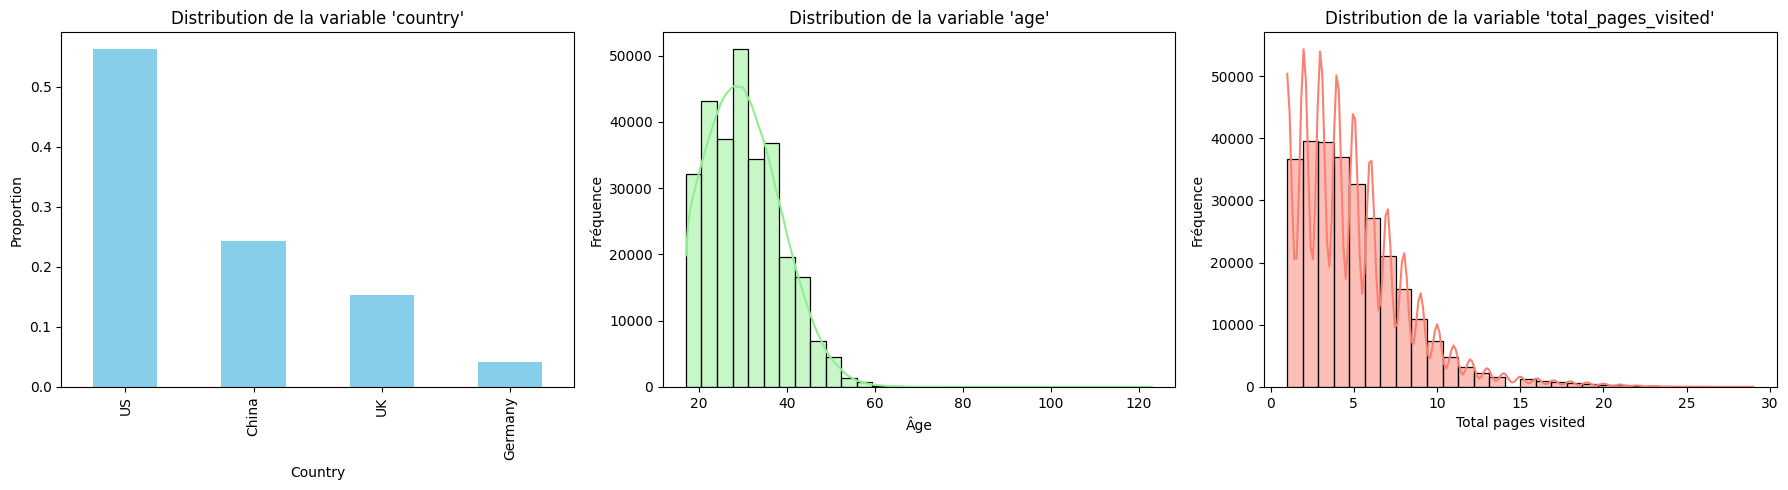

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Variable "country"
dataset['country'].value_counts(normalize=True).plot.bar(ax=axes[0], color='skyblue')
axes[0].set_title("Distribution de la variable 'country'")
axes[0].set_ylabel("Proportion")
axes[0].set_xlabel("Country")

# Variable "age"
sns.histplot(dataset['age'].dropna(), bins=30, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title("Distribution de la variable 'age'")
axes[1].set_xlabel("Âge")
axes[1].set_ylabel("Fréquence")

# Variable "total_pages_visited"
sns.histplot(dataset['total_pages_visited'].dropna(), bins=30, kde=True, ax=axes[2], color='salmon')
axes[2].set_title("Distribution de la variable 'total_pages_visited'")
axes[2].set_xlabel("Total pages visited")
axes[2].set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

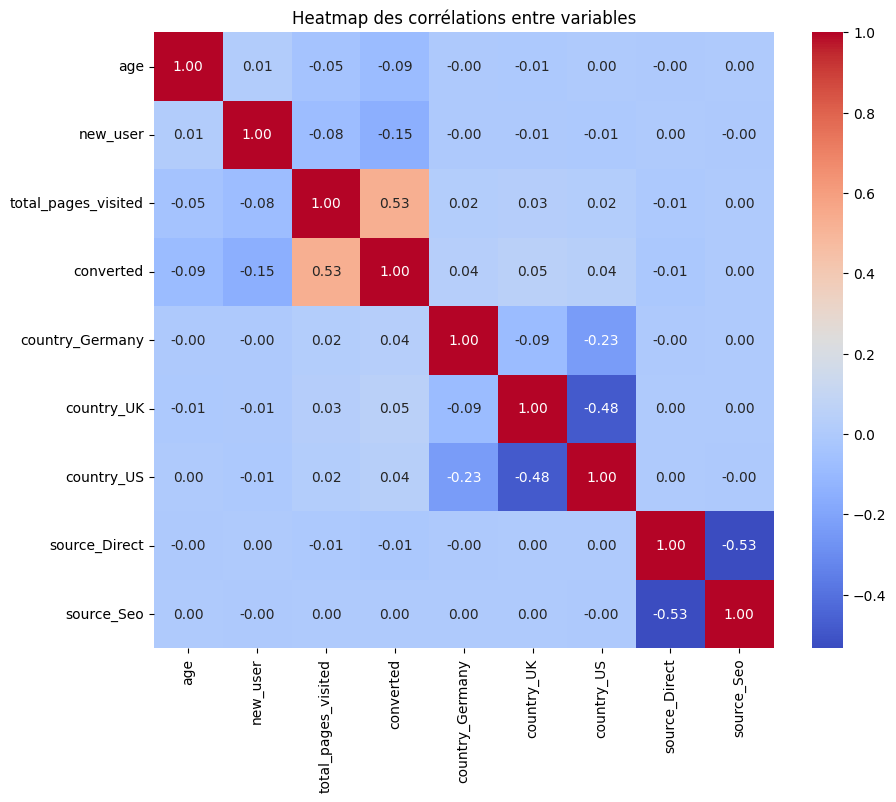

In [111]:
# HEATMAP globale
# Calcul de la matrice de corrélation
dataset_encoded = pd.get_dummies(dataset, drop_first=True)
corr = dataset_encoded.corr()

# Affichage de la heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Heatmap des corrélations entre variables")
plt.show()

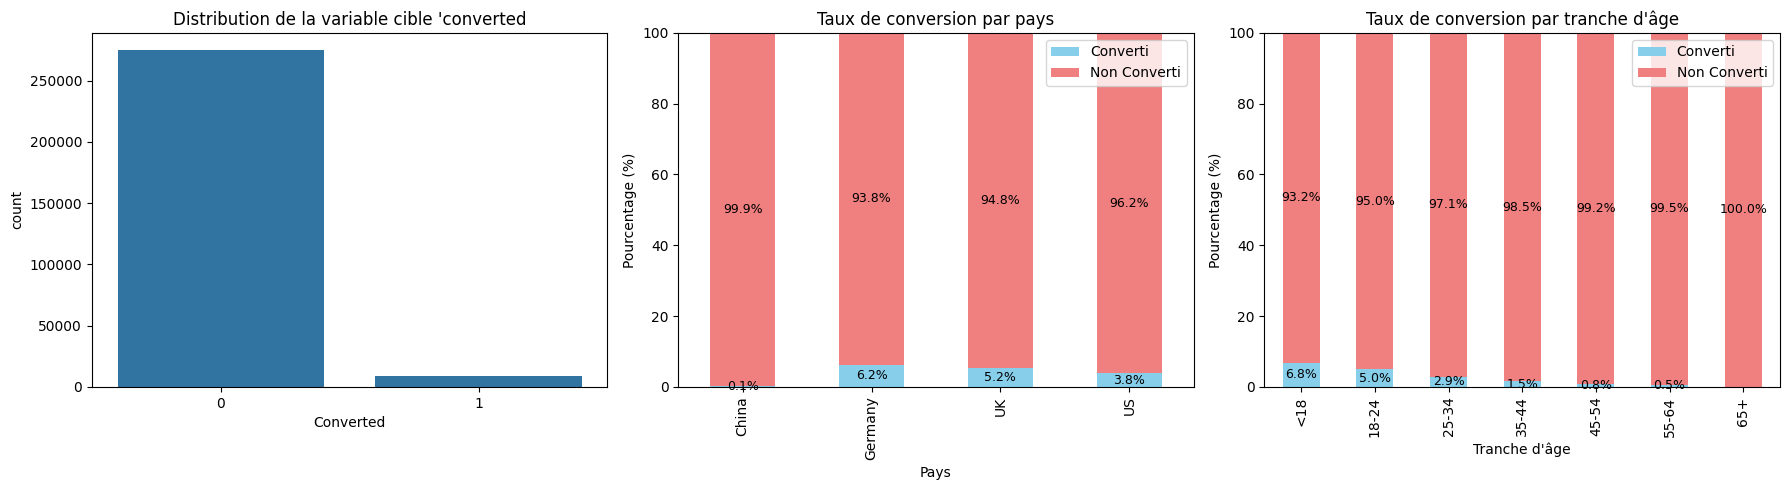

Taux de conversion (en pourcentage) : 3.23 %


In [138]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Countplot Converted
sns.countplot(x='converted', data=dataset, ax=axes[0])
axes[0].set_title("Distribution de la variable cible 'converted")
axes[0].set_xlabel("Converted")
axes[0].set_ylabel("count")

# Taux de conversion par pays
conversion_par_pays = pd.crosstab(dataset['country'], dataset['converted'], normalize='index') * 100
conversion_par_pays.columns = ['Non Converti', 'Converti']
conversion_par_pays = conversion_par_pays[['Converti', 'Non Converti']]

conversion_par_pays.plot(kind='bar', stacked=True, ax=axes[1], color=['skyblue', 'lightcoral'])
axes[1].set_ylabel("Pourcentage (%)")
axes[1].set_xlabel("Pays")
axes[1].set_title("Taux de conversion par pays")
axes[1].legend(title="", loc="upper right")
axes[1].set_ylim(0, 100)

# Ajouter les valeurs
for p in axes[1].patches:
    if p.get_height() > 0:
        axes[1].text(p.get_x() + p.get_width()/2, p.get_y() + p.get_height()/2,
                     f'{p.get_height():.1f}%', ha='center', va='center', fontsize=9)

# Taux de conversion par tranche d'âge
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['<18','18-24','25-34','35-44','45-54','55-64','65+']
dataset['age_group'] = pd.cut(dataset['age'], bins=bins, labels=labels)

conversion_par_age = pd.crosstab(dataset['age_group'], dataset['converted'], normalize='index') * 100
conversion_par_age.columns = ['Non Converti', 'Converti']
conversion_par_age = conversion_par_age[['Converti', 'Non Converti']]

conversion_par_age.plot(kind='bar', stacked=True, ax=axes[2], color=['skyblue', 'lightcoral'])
axes[2].set_ylabel("Pourcentage (%)")
axes[2].set_xlabel("Tranche d'âge")
axes[2].set_title("Taux de conversion par tranche d'âge")
axes[2].legend(title="", loc="upper right")
axes[2].set_ylim(0, 100)

# Ajouter les valeurs
for p in axes[2].patches:
    if p.get_height() > 0:
        axes[2].text(p.get_x() + p.get_width()/2, p.get_y() + p.get_height()/2,
                     f'{p.get_height():.1f}%', ha='center', va='center', fontsize=9)

# Ajustement
plt.tight_layout()
plt.show()

# Taux de conversion
taux_conversion = (dataset["converted"].mean() * 100).round(2)
print(f"Taux de conversion (en pourcentage) : {taux_conversion} %")

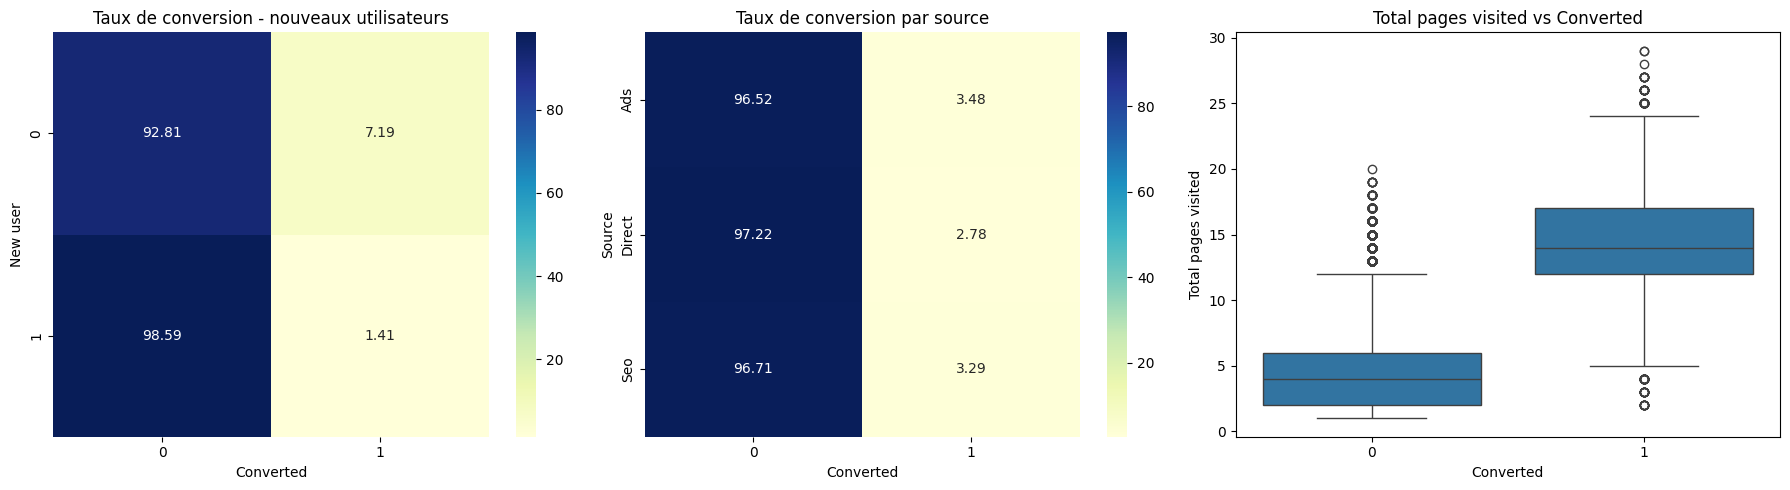

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Heatmap new_user
sns.heatmap(new_user_converted, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Taux de conversion - nouveaux utilisateurs")
axes[0].set_ylabel("New user")
axes[0].set_xlabel("Converted")

# Heatmap source (seo = référence naturelle, ads = publicité, direct = accès direct)
sns.heatmap(source_converted, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Taux de conversion par source")
axes[1].set_ylabel("Source")
axes[1].set_xlabel("Converted")

# Boxplot Total pages vs Converted
sns.boxplot(x='converted', y='total_pages_visited', data=dataset, ax=axes[2])
axes[2].set_title("Total pages visited vs Converted")
axes[2].set_xlabel("Converted")
axes[2].set_ylabel("Total pages visited")

plt.tight_layout()
plt.show()

### Synthèse
- 3.23 % d'abonnements sur le nombre de connexions
- Profil des utlisateurs : 30 ans en moyenne, 56 % des USA
- Habitudes de navigation : visite 4 pages en moyenne

Conversion en abonnement
- Plus de conversion en Allemagne que dans les autres pays
- Les utilisateurs qui s'abonnent ne sont pas nécessairement des nouveaux utilisateurs
- Les moins de 18 ans s'abonnent plus que les autres catégories d'âge
- Plus un utilisateur visite de pages, plus il a de chances de convertir (corrélation positive, 0.53)

_Rq:_ Les colonnes country_UK et country_US sont issues d’un one-hot encoding. La corrélation négative (-0,48) indique que si un utilisateur est du Royaume-Uni (country_UK = 1), il n’est généralement pas des États-Unis (country_US = 0). Ce n’est pas surprenant : un utilisateur ne peut pas être simultanément des deux pays.

# Prétraitement

In [152]:
# Copie de sécurité
X = dataset_encoded.copy().drop(columns=['converted'])

# Cible
y = dataset['converted']

# Variables numériques à standardiser
num_features = ['age', 'total_pages_visited']

# Appliquer le scaler
scaler = StandardScaler()
X[num_features] = scaler.fit_transform(X[num_features])

print("Shape finale :", X.shape)
print("Colonnes :", X.columns.tolist()[:10])
X.head()


Shape finale : (284580, 8)
Colonnes : ['age', 'new_user', 'total_pages_visited', 'country_Germany', 'country_UK', 'country_US', 'source_Direct', 'source_Seo']


,age,new_user,total_pages_visited,country_Germany,country_UK,country_US,source_Direct,source_Seo
0,-1.035979,1,-0.859743,False,False,False,True,False
1,-1.156945,1,-0.560520,False,True,False,False,False
2,-1.277911,0,2.730933,True,False,False,False,True
3,-0.915013,1,-0.560520,False,False,True,False,True
4,-0.310182,1,-0.560520,False,False,True,True,False


## Modèle de base

In [160]:
features_list = ['total_pages_visited']
numeric_indices = [0]
categorical_indices = []
target_variable = 'converted'

X = dataset_encoded.loc[:, features_list]
Y = dataset_encoded.loc[:, target_variable]

print('Explanatory variables : ', X.columns)
print()

Explanatory variables :  Index(['total_pages_visited'], dtype='object')



In [ ]:
# Divide dataset Train set & Test set 
print("Dividing into train and test sets...")
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=0)
print("...Done.")
print()

Dividing into train and test sets...
...Done.



In [ ]:
# Put here all the preprocessings
print("Encoding categorical features and standardizing numerical features...")

featureencoder = StandardScaler()
X_train = featureencoder.fit_transform(X_train)
print("...Done")
print(X_train[0:5,:])

Encoding categorical features and standardizing numerical features...
...Done
[[-0.26070136]
 [ 0.93728655]
 [-0.85969532]
 [-0.56019834]
 [-0.26070136]]


In [ ]:
# Train model
print("Train model...")
classifier = LogisticRegression() # 
classifier.fit(X_train, Y_train)
print("...Done.")

Train model...
...Done.


In [ ]:
# Predictions on training set
print("Predictions on training set...")
Y_train_pred = classifier.predict(X_train)
print("...Done.")
print(Y_train_pred)
print()

Predictions on training set...
...Done.
[0 0 0 ... 0 0 0]



In [ ]:
# Use X_test, and the same preprocessings as in training pipeline, 
# but call "transform()" instead of "fit_transform" methods (see example below)

print("Encoding categorical features and standardizing numerical features...")

X_test = featureencoder.transform(X_test)
print("...Done")
print(X_test[0:5,:])

Encoding categorical features and standardizing numerical features...
...Done
[[ 0.63778957]
 [ 0.03879562]
 [-0.26070136]
 [-0.26070136]
 [ 0.63778957]]


In [ ]:
# Predictions on test set
print("Predictions on test set...")
Y_test_pred = classifier.predict(X_test)
print("...Done.")
print(Y_test_pred)
print()

Predictions on test set...
...Done.
[0 0 0 ... 0 0 0]



In [ ]:
# WARNING : Use the same score as the one that will be used by Kaggle !
# Here, the f1-score will be used to assess the performances on the leaderboard
print("f1-score on train set : ", f1_score(Y_train, Y_train_pred))
print("f1-score on test set : ", f1_score(Y_test, Y_test_pred))

f1-score on train set :  0.6938517686692869
f1-score on test set :  0.7060240963855422


In [ ]:
# You can also check more performance metrics to better understand what your model is doing
print("Confusion matrix on train set : ")
print(confusion_matrix(Y_train, Y_train_pred))
print()
print("Confusion matrix on test set : ")
print(confusion_matrix(Y_test, Y_test_pred))
print()

Confusion matrix on train set : 
[[246817   1082]
 [  3280   4943]]

Confusion matrix on test set : 
[[27384   117]
 [  371   586]]



In [ ]:
# Entrainement final sur l'ensemble du dataset
# Concatenate our train and test set to train your best classifier on all data with labels
X = np.append(X_train,X_test,axis=0)
Y = np.append(Y_train,Y_test)

classifier.fit(X,Y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
# Read data without labels
data_without_labels = pd.read_csv('conversion_data_test.csv')
print('Prediction set (without labels) :', data_without_labels.shape)

# Warning : check consistency of features_list (must be the same than the features 
# used by your best classifier)
features_list = ['total_pages_visited']
X_without_labels = data_without_labels.loc[:, features_list]

# Convert pandas DataFrames to arrays before using scikit-learn
print("Convert pandas DataFrames to arrays...")
X_without_labels = X_without_labels.values
print("...Done")

print(X_without_labels[0:5,:])

Prediction set (without labels) : (31620, 5)
Convert pandas DataFrames to arrays...
...Done
[[16]
 [ 5]
 [ 1]
 [ 6]
 [ 3]]


In [ ]:
# WARNING : PUT HERE THE SAME PREPROCESSING AS FOR YOUR TEST SET
# CHECK YOU ARE USING X_without_labels
print("Encoding categorical features and standardizing numerical features...")

X_without_labels = featureencoder.transform(X_without_labels)
print("...Done")
print(X_without_labels[0:5,:])

Encoding categorical features and standardizing numerical features...
...Done
[[ 3.33326238]
 [ 0.03879562]
 [-1.15919229]
 [ 0.3382926 ]
 [-0.56019834]]


c:\Users\NLefort\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



In [ ]:
# Make predictions and dump to file
# WARNING : MAKE SURE THE FILE IS A CSV WITH ONE COLUMN NAMED 'converted' AND NO INDEX !
# WARNING : FILE NAME MUST HAVE FORMAT 'conversion_data_test_predictions_[name].csv'
# where [name] is the name of your team/model separated by a '-'
# For example : [name] = AURELIE-model1
data = {
    'converted': classifier.predict(X_without_labels)
}

Y_predictions = pd.DataFrame(columns=['converted'],data=data)
Y_predictions.to_csv('conversion_data_test_predictions_EXAMPLE.csv', index=False)

## Amélioration du modèle

Partie 1 : EDA (Exploration des données) et modèle de base



4/ Modèle de base




Partie 2 : Amélioration du modèle
1/ Ingénierie des features

Créer de nouvelles variables si possible

Regrouper certaines catégories rares

Détecter et supprimer les variables peu informatives

2/ Sélection de features

Méthodes comme : SelectKBest, importance des features (Random Forest), Lasso

3/ Essayer plusieurs modèles

Arbres de décision / Random Forest / XGBoost / LightGBM / CatBoost

Comparer les modèles avec F1 score

4/ Optimisation des hyperparamètres

Recherche sur grille (GridSearchCV) ou recherche aléatoire (RandomizedSearchCV)

Évaluer le modèle sur validation pour éviter le surapprentissage

Partie 3 : Prédictions sur data_test.csv

Une fois le meilleur modèle sélectionné :

predictions = best_model.predict(data_test)
submission = pd.DataFrame({"Id": data_test.index, "target": predictions})
submission.to_csv("predictions.csv", index=False)


Envoyer ce fichier à ton professeur / assistant pour le classement.

Partie 4 : Analyse du modèle et recommandations

Identifier les variables les plus importantes (coefficients ou importance des features)

Identifier les leviers d’action possibles pour améliorer le taux de conversion :

Ex : si l’âge ou la source de trafic est très influent → actions marketing ciblées

Rédiger un court rapport avec recommandations concrètes pour l’équipe de la newsletter.

Livrables finaux

EDA avec visualisations pertinentes

Au moins un modèle entraîné et évalué (F1, confusion matrix)

Fichier predictions.csv pour la soumission

Analyse des paramètres et recommandations actionnables